# 01. PyTorch Workflow Fundamentals

This notebook covers the PyTorch Workflows

**Resources**
1. Notebook: https://www.learnpytorch.io/01_pytorch_workflow/
2. Video: https://www.youtube.com/watch?v=V_xro1bcAuA&t=5277s


## Setup & Environment Check

Import the required libraries and check which device (CPU or GPU/ROCm) is available, so later tensor operations can be placed on the right device.


In [64]:
# Capture the runtime details so we know which image-processing paths are available.
import platform
import torch
from torch import nn as nn
import warnings
import torch
import numpy as np
import matplotlib.pyplot as plt

# Silence warnings so the notebook output stays focused on the examples.
warnings.filterwarnings("ignore")

print(f"--- System Information ---")
print(f"Platform: {platform.platform()}")
print(f"Python:   {platform.python_version()}")
print(f"PyTorch:  {torch.__version__}")

print(f"\n--- GPU/ROCm Accelerators ---")
cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")

if cuda_available:
    print(f"Device Count:   {torch.cuda.device_count()}")
    print(f"Primary Device: {torch.cuda.get_device_name(0)}")
    DEVICE = torch.device("cuda:0")
else:
    print("Optimization Note: No CUDA-capable GPU detected. Operations will run on CPU.")
    DEVICE = torch.device("cpu")


--- System Information ---
Platform: Windows-11-10.0.26200-SP0
Python:   3.12.13
PyTorch:  2.9.1+rocm7.2.1

--- GPU/ROCm Accelerators ---
CUDA Available: True
Device Count:   1
Primary Device: AMD Radeon RX 7900 XT


## Data (prep and loading)
linear regression with known parameters.

In [65]:
# Known parameters for the workflow.
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [66]:
len(X), len(y)

(50, 50)

### Train/test split

In [67]:
# Train/test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

### Visualize

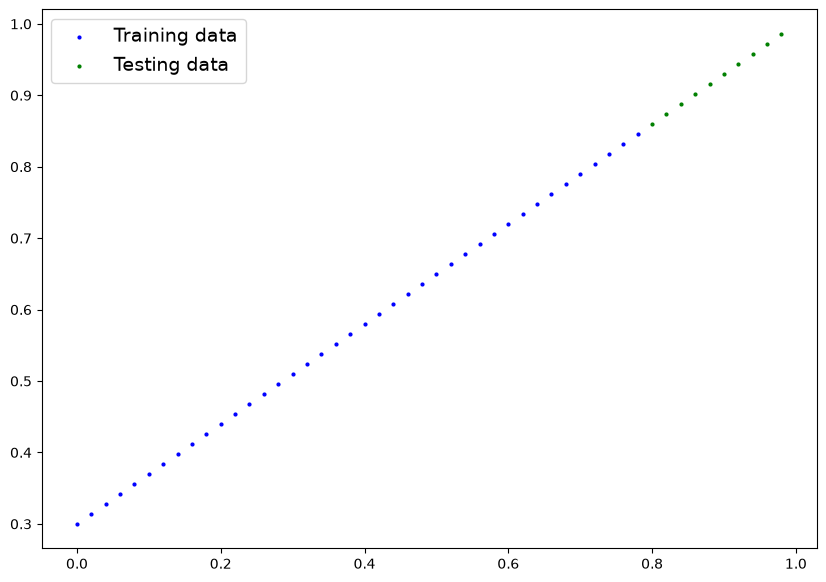

In [68]:
def plot_predictions(train_data, train_labels, test_data, test_labels, predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10, 7))
    # Plot training data in blue, test data in green, and predictions in red.
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    plt.legend(prop={"size": 14})
    plt.show()

plot_predictions(X_train, y_train, X_test, y_test)

## Building Model (Linear Regression)
1. Model flow ?
- Model starts with random values
- Adjust values to better fit to the weight/bais values.

2. Main algorithms
- Gradient descent
- Backpropagation

In [69]:
# Linear regression model
class LinearRegressionModel(nn.Module): # nn.Module is the base class for all neural network modules in PyTorch
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, # Start with a random weight and bias and adjust them during training to reach the optimal values.
                                                requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, # Start with a random weight and bias and adjust them during training to reach the optimal values.
                                             requires_grad=True, dtype=torch.float))

    # The forward method defines the computation performed at every call.
    def forward(self, x: torch.Tensor) -> torch.Tensor: # x is the input tensor, and the method returns the output tensor after applying the linear transformation.
        return self.weights * x + self.bias # linear formula

### PyTorch model building essentials

In [70]:
# Random seed
torch.manual_seed(42)

model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [71]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making Prediction

Making predictions with the model using torch.inference_mode() to avoid tracking gradients during inference, which saves memory and computations.


In [72]:
with torch.inference_mode(): # Faster than torch.no_grad() and more explicit about the intent to run inference.
    y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

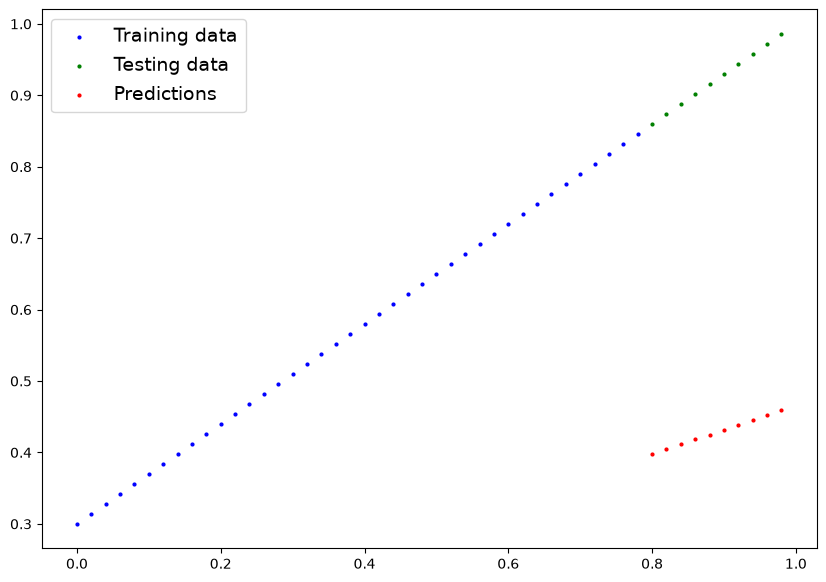

In [73]:
plot_predictions(X_train, y_train, X_test, y_test, y_preds)

### Training Model

In [74]:
# Loss function setup
loss_fn = nn.L1Loss() # Mean Absolute Error (MAE)

# Setup optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01) # Stochastic Gradient Descent (SGD) optimizer

In [96]:
torch.manual_seed(42)
EPOCHS = 100

for epoch in range(EPOCHS):
    model_0.train() # Set the model to training mode

    # 1. Forward pass: compute predicted y by passing X to the model
    y_pred = model_0(X_train)

    # 2. Compute and print loss
    loss = loss_fn(y_pred, y_train)
    print(f"Epoch {epoch}: Loss = {loss.item():.7f}")

    # 3. Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad() 

    # 4. Backward pass: compute gradient of the loss with respect to model parameters
    loss.backward() 

    # 5. Update parameters based on gradients
    optimizer.step()
    

Epoch 0: Loss = 0.0025885
Epoch 1: Loss = 0.0089325
Epoch 2: Loss = 0.0025885
Epoch 3: Loss = 0.0089325
Epoch 4: Loss = 0.0025885
Epoch 5: Loss = 0.0089325
Epoch 6: Loss = 0.0025885
Epoch 7: Loss = 0.0089325
Epoch 8: Loss = 0.0025885
Epoch 9: Loss = 0.0089325
Epoch 10: Loss = 0.0025885
Epoch 11: Loss = 0.0089325
Epoch 12: Loss = 0.0025885
Epoch 13: Loss = 0.0089325
Epoch 14: Loss = 0.0025885
Epoch 15: Loss = 0.0089325
Epoch 16: Loss = 0.0025885
Epoch 17: Loss = 0.0089325
Epoch 18: Loss = 0.0025885
Epoch 19: Loss = 0.0089325
Epoch 20: Loss = 0.0025885
Epoch 21: Loss = 0.0089325
Epoch 22: Loss = 0.0025885
Epoch 23: Loss = 0.0089325
Epoch 24: Loss = 0.0025885
Epoch 25: Loss = 0.0089325
Epoch 26: Loss = 0.0025885
Epoch 27: Loss = 0.0089325
Epoch 28: Loss = 0.0025885
Epoch 29: Loss = 0.0089325
Epoch 30: Loss = 0.0025885
Epoch 31: Loss = 0.0089325
Epoch 32: Loss = 0.0025885
Epoch 33: Loss = 0.0089325
Epoch 34: Loss = 0.0025885
Epoch 35: Loss = 0.0089325
Epoch 36: Loss = 0.0025885
Epoch 37: L

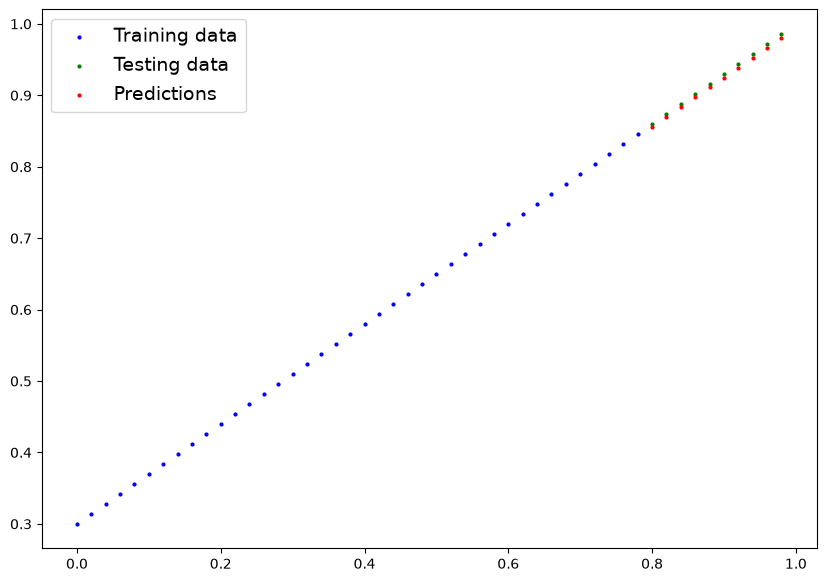

In [99]:
with torch.inference_mode():
    y_preds = model_0(X_test)

plot_predictions(X_train, y_train, X_test, y_test, y_preds)

In [97]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6951])), ('bias', tensor([0.2993]))])

## Video Timestamp: Testing Loop
06:49:31